In [5]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as py
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score


In [6]:
#CreditCarddf = pd.read_csv("D:\\Veena\\Certificate Program in AI and ML\\Certificate-Program-in-AIML-IIT-Patna\\MODULE 2 - CLASSICAL ML\\Dataset\\creditcard.csv")
#CreditCarddf.head(10)

import zipfile
#Personal lap path
zip_path = r"D:\Veena\Certificate Program in AI and ML\Certificate-Program-in-AIML-IIT-Patna\MODULE 2 - CLASSICAL ML\Dataset.zip"
#office lap path
#zip_path = r"E:\Veena\Certificate-Program-in-AIML-IIT-Patna\MODULE 2 - CLASSICAL ML\Dataset.zip"

with zipfile.ZipFile(zip_path) as z:
    mallDF = pd.read_csv(z.open("Dataset/mall_customers.csv"))

mallDF.head(10)

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


In [ ]:
#Checking for any null values.
mallDF.isna().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

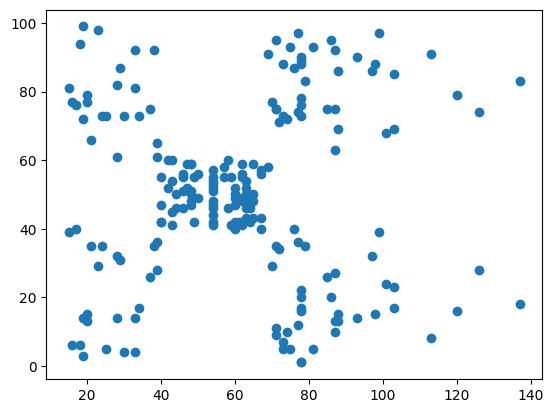

In [10]:
## Scatter plot on Annual income and spending,. to check if there is any grouping in dataset.
py.scatter(mallDF['Annual Income (k$)'],mallDF['Spending Score (1-100)'])

### Building K-MEANS ALGO

In [ ]:
X = mallDF[['Annual Income (k$)','Spending Score (1-100)']].values

print(f"Shape of X:: {X.shape}")

#dataFrameName[rows,columns]
#X[:,0].min() - : means select all rows, 0 means select first column. min of the first column.
print(f"Income range before scaling:: {X[:,0].min()} to {X[:,0].max()}")


Shape of X:: (200, 2)
Income range before scaling:: 15 to 137


In [17]:
#Scaling data

St = StandardScaler()
X_scaled = St.fit_transform(X)

print(f"Income range after scaling:: {X_scaled[:,0].min()} to {X_scaled[:,0].max()}")

    

Income range after scaling:: -1.7389991930659485 to 2.9176711658902788


In [18]:
k_range = range(2,20)

print(k_range)

range(2, 20)


In [20]:
km = KMeans(n_clusters=3, random_state=42,n_init='auto')
km.fit(X_scaled)
print(f"Lables/clustures assigned: {km.labels_}")
print(f"Silloute score::: {silhouette_score(X_scaled,km.labels_)}");

Lables/clustures assigned: [2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1
 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0
 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1]
Silloute score::: 0.46658474419000145


In [26]:
sillScores=[]
for i in k_range:
    kms = KMeans(n_clusters=i,random_state=42,n_init='auto')
    kms.fit(X_scaled)
    sillScores.append(silhouette_score(X_scaled,kms.labels_))

for income,score in zip(k_range,sillScores):
    print(f"Clusture: {income} Silloute scores: {score}")


Clusture: 2 Silloute scores: 0.3973270007887498
Clusture: 3 Silloute scores: 0.46658474419000145
Clusture: 4 Silloute scores: 0.49434988482196784
Clusture: 5 Silloute scores: 0.5546571631111091
Clusture: 6 Silloute scores: 0.5138257534676561
Clusture: 7 Silloute scores: 0.50200146805547
Clusture: 8 Silloute scores: 0.4550112502601921
Clusture: 9 Silloute scores: 0.4566624374485964
Clusture: 10 Silloute scores: 0.44475993501732874
Clusture: 11 Silloute scores: 0.4456479428438176
Clusture: 12 Silloute scores: 0.3713686676601066
Clusture: 13 Silloute scores: 0.38264093256138937
Clusture: 14 Silloute scores: 0.3874613064238352
Clusture: 15 Silloute scores: 0.42716678409862796
Clusture: 16 Silloute scores: 0.417134622667315
Clusture: 17 Silloute scores: 0.40816206264216226
Clusture: 18 Silloute scores: 0.40586772113831343
Clusture: 19 Silloute scores: 0.40027902051127057


Text(0.5, 1.0, 'No.of clustures (Vs) Sillouete scores')

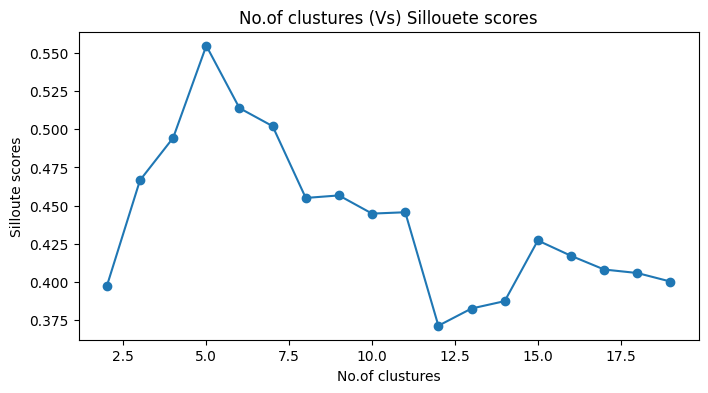

In [27]:
py.figure(figsize=(8,4))
py.plot(k_range,sillScores,'o-')
py.xlabel("No.of clustures")
py.ylabel("Silloute scores")
py.title("No.of clustures (Vs) Sillouete scores")

In [31]:
kmFinal = KMeans(n_clusters=5, random_state=42,n_init='auto')
labels = kmFinal.fit_predict(X_scaled)
mallDF['Cluster'] = labels
print(f"Lables/clustures assigned: {kmFinal.labels_}")
display(mallDF.head(10))
print(f"Silloute score::: {silhouette_score(X_scaled,kmFinal.labels_)}");

Lables/clustures assigned: [4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4
 2 4 2 4 2 4 0 4 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 3 1 0 1 3 1 3 1 0 1 3 1 3 1 3 1 3 1 0 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1]


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4
5,6,Female,22,17,76,2
6,7,Female,35,18,6,4
7,8,Female,23,18,94,2
8,9,Male,64,19,3,4
9,10,Female,30,19,72,2


Silloute score::: 0.5546571631111091


In [32]:
mallDF['Cluster'].value_counts()

Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64

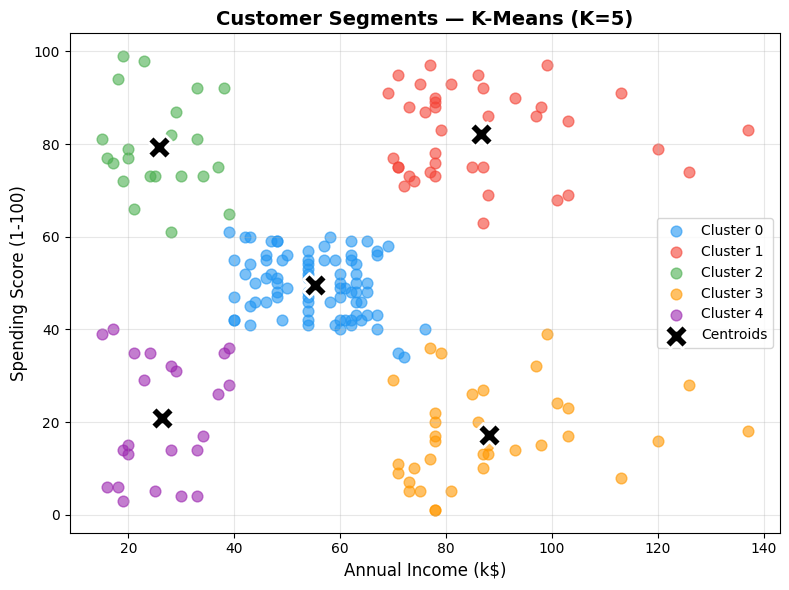

In [33]:
# Visualize the clusters
fig, ax = py.subplots(figsize=(8, 6))

colors = ['#2196F3', '#F44336', '#4CAF50', '#FF9800', '#9C27B0']
cluster_names = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4']

for i in range(5):
    mask = labels == i
    ax.scatter(X[mask, 0], X[mask, 1], c=colors[i], alpha=0.6, s=60, label=cluster_names[i])

# Plot centroids (unscaled for interpretation)
centers = St.inverse_transform(kmFinal.cluster_centers_)
ax.scatter(centers[:, 0], centers[:, 1], c='black', marker='X', s=300,
           zorder=5, edgecolors='white', linewidth=2, label='Centroids')

ax.set_xlabel('Annual Income (k$)', fontsize=12)
ax.set_ylabel('Spending Score (1-100)', fontsize=12)
ax.set_title('Customer Segments — K-Means (K=5)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
py.tight_layout()
py.show()

In [35]:
# Cluster profiles: mean of each feature per cluster
print("Cluster Profiles (Mean Values):")
print("=" * 60)
profile = mallDF.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(1)
print(profile)

Cluster Profiles (Mean Values):
          Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                  
0        42.7                55.3                    49.5
1        32.7                86.5                    82.1
2        25.3                25.7                    79.4
3        41.1                88.2                    17.1
4        45.2                26.3                    20.9
